In [1]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchvision import transforms
from PIL import Image
import pickle
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F
import pandas as pd

In [2]:
import random
import torch
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
# load_any_dataset.py を使うことで、クラス名が違うpkl（広島データ・島根データ）でも
# 同じように読み込めるようにする。
import sys
sys.path.append(r"C:\\Users\\hirok\\OneDrive\\Desktop\\CrZ\\simane\\MakeDataSet")  # load_any_dataset.pyがあるフォルダ（要調整）
from load_any_dataset import load_dataset

class photo_dataset:
    def __init__(self):
        self.__KeyName = ["No", "DEM", "Mask", "GeoInfo", "EPSG", "Max_H", "Min_H","AirPhoto"]
        self.No = []
        self.DEM = []
        self.Mask = []
        self.GeoInfo = []
        self.EPSG = []
        self.Max_H = []
        self.Min_H = []
        self.AirPhoto=[]

    def key(self):
        return self.__KeyName

path = "D:\\NewDatasModel\\DataSet\\Hiroshima\\hiroshima_sam_apm.pkl"
dataset = load_dataset(path)
print(len(dataset.No))
print(dataset.DEM[0].shape)

38148
(128, 128)


In [5]:
print(dataset.GeoInfo[0])

(132.40625, 4.882812499995559e-05, 0.0, 34.025, 0.0, -3.2552082031234164e-05)


In [6]:

dataset2 = photo_dataset()
dataset3 = photo_dataset()
#images2 = []
for i in range(len(dataset.No)):
    if np.max(np.array(dataset.Mask[i])) >= 1:
        dataset2.DEM.append(dataset.DEM[i])
        dataset2.Mask.append(dataset.Mask[i])
        dataset2.No.append(dataset.No[i])
        dataset2.GeoInfo.append(dataset.GeoInfo[i])
        dataset2.EPSG.append(dataset.EPSG[i])
        dataset2.Max_H.append(dataset.Max_H[i])
        dataset2.Min_H.append(dataset.Min_H[i])
        dataset2.AirPhoto.append(dataset.AirPhoto[i])
    else:
        dataset3.DEM.append(dataset.DEM[i])
        dataset3.Mask.append(dataset.Mask[i])
        dataset3.No.append(dataset.No[i])
        dataset3.GeoInfo.append(dataset.GeoInfo[i])
        dataset3.EPSG.append(dataset.EPSG[i])
        dataset3.Max_H.append(dataset.Max_H[i])
        dataset3.Min_H.append(dataset.Min_H[i])
        dataset3.AirPhoto.append(dataset.AirPhoto[i])
        
        #images2.append(images[i])
print(len(dataset2.DEM))
print(len(dataset2.Mask))
print(len(dataset3.DEM))
del dataset

14816
14816
23332


In [7]:
from scipy.ndimage import gaussian_filter
for i in range(len(dataset2.No)):
    dataset2.Mask[i] = np.array(dataset2.Mask[i])
    dataset2.Mask[i] = dataset2.Mask[i].astype(np.uint8) * 255
    dataset2.Mask[i] = gaussian_filter(dataset2.Mask[i], sigma=1)
    dataset2.Mask[i] = (dataset2.Mask[i] > 0).astype(np.uint8)

for i in range(len(dataset3.No)):
    dataset3.Mask[i] = np.array(dataset3.Mask[i])
    dataset3.Mask[i] = dataset3.Mask[i].astype(np.uint8) * 255
    dataset3.Mask[i] = gaussian_filter(dataset3.Mask[i], sigma=1)
    dataset3.Mask[i] = (dataset3.Mask[i] > 0).astype(np.uint8)

In [8]:
import random

random.seed(42)  # 好きな整数

# ============================================================
# 背景タイル（警戒区域を含まないタイル）の追加割合を管理する。
#
# 「配列番号」として dataset2.BgSourceIndex を追加し、各タイルについて
#   - 元々マスクを含むタイルなら None
#   - 背景として追加されたタイルなら dataset3 内での元インデックス
# を記録する。これにより、割合(bg_ratio)を変えて何度も試しても、
# 「今回どのタイルが追加されたか」を後から dataset2.BgSourceIndex で確認できる。
#
# 選択方法は「シャッフル順を固定し、先頭からn_add件を取る」方式にしている。
# そのため、小さい割合で選ばれるタイルは、必ず大きい割合でも選ばれる
# （入れ子構造）。異なる割合の実験結果を、タイルの追加のされ方という
# 観点でも一貫して比較できる。
#
# このセルは何度再実行しても安全（bg_ratioを変えて再実行するたびに、
# 一度「元々のマスクありタイルだけ」の状態に戻してから追加し直すため、
# 重複や蓄積は起きない）。
# ============================================================

if not hasattr(dataset2, "_base_count"):
    # 初回実行時：元々のマスクありタイル数を記録しておく
    dataset2._base_count = len(dataset2.No)
    dataset2.BgSourceIndex = [None] * dataset2._base_count
else:
    # 2回目以降：背景タイルを追加する前の状態（元のマスクありタイルのみ）に戻す
    base_n = dataset2._base_count
    dataset2.DEM = dataset2.DEM[:base_n]
    dataset2.Mask = dataset2.Mask[:base_n]
    dataset2.No = dataset2.No[:base_n]
    dataset2.GeoInfo = dataset2.GeoInfo[:base_n]
    dataset2.EPSG = dataset2.EPSG[:base_n]
    dataset2.Max_H = dataset2.Max_H[:base_n]
    dataset2.Min_H = dataset2.Min_H[:base_n]
    dataset2.AirPhoto = dataset2.AirPhoto[:base_n]
    dataset2.BgSourceIndex = dataset2.BgSourceIndex[:base_n]

# シャッフル順を固定（seedを変えない限り、毎回同じ並び順になる）
bg_order = list(range(len(dataset3.No)))
random.shuffle(bg_order)

# ---- ここを変えて割合を実験する（例: 0.1 なら背景タイルを10%分追加） ----
bg_ratio = 0.0
# --------------------------------------------------------------

n_add = int(len(dataset3.No) * bg_ratio)
selected_indices = bg_order[:n_add]

for i in selected_indices:
    dataset2.DEM.append(dataset3.DEM[i])
    dataset2.Mask.append(dataset3.Mask[i])
    dataset2.No.append(dataset3.No[i])
    dataset2.GeoInfo.append(dataset3.GeoInfo[i])
    dataset2.EPSG.append(dataset3.EPSG[i])
    dataset2.Max_H.append(dataset3.Max_H[i])
    dataset2.Min_H.append(dataset3.Min_H[i])
    dataset2.AirPhoto.append(dataset3.AirPhoto[i])
    dataset2.BgSourceIndex.append(i)  # dataset3内での元インデックスを記録

print("マスクあり元データ数:", dataset2._base_count)
print(f"追加した背景データ数: {n_add} (割合: {bg_ratio*100:.1f}%)")
print("最終データ数:", len(dataset2.No))
print("追加された背景タイルのdataset3内インデックス（先頭10件）:", selected_indices[:10])

# 複数の割合を試す運用を想定し、dataset3は自動では解放しない。
# 全ての割合での実験が終わったら、手動で次を実行してメモリを解放してください：
#   del dataset3; import gc; gc.collect()

マスクあり元データ数: 14816
追加した背景データ数: 0 (割合: 0.0%)
最終データ数: 14816
追加された背景タイルのdataset3内インデックス（先頭10件）: []


In [9]:
# ============================================================
# メモリ節約版:
#  - AirPhoto/Maskはuint8のまま保持し、float化(/255.0含む)は
#    DualInputDatasetの__getitem__内でサンプル単位に行う
#    （float32で全件保持するとAirPhotoだけで4倍のメモリを消費するため）
#  - torch.tensor()ではなくtorch.from_numpy()を使い、余分なコピーを避ける
# ============================================================
dataset2.DEM = np.array(dataset2.DEM, dtype=np.float32)
dataset2.AirPhoto = np.array(dataset2.AirPhoto, dtype=np.uint8)
dataset2.Mask = np.array(dataset2.Mask, dtype=np.uint8)

dataset2.DEM = np.expand_dims(
    dataset2.DEM,
    axis=1)

dataset2.AirPhoto = np.transpose(
    dataset2.AirPhoto,
    (0, 3, 1, 2)
)
# ここでは/255.0しない（uint8のまま持つ。DualInputDataset側で正規化する）

dataset2.Mask = np.expand_dims(
    dataset2.Mask,
    axis=1
)


# tensor化（from_numpyはnumpy配列とメモリを共有するため、コピーが発生しない）
dataset2.DEM = torch.from_numpy(dataset2.DEM)          # float32のまま
dataset2.AirPhoto = torch.from_numpy(dataset2.AirPhoto)  # uint8のまま
dataset2.Mask = torch.from_numpy(dataset2.Mask)          # uint8のまま

In [10]:
# ==========================================
# ⑦ shape確認
# ==========================================
print("AirPhoto shape :", dataset2.AirPhoto.shape)
print("DEM shape  :", dataset2.DEM.shape)
print("Mask shape  :", dataset2.Mask.shape)

# Input : [batch, 2, H, W]
# Mask  : [batch, 1, H, W]

AirPhoto shape : torch.Size([14816, 3, 128, 128])
DEM shape  : torch.Size([14816, 1, 128, 128])
Mask shape  : torch.Size([14816, 1, 128, 128])


In [11]:
from sklearn.model_selection import train_test_split

# まずtestを切り出す（最終評価専用。学習中は一切参照しない）
dem_trainval, dem_test, air_trainval, air_test, y_trainval, y_test, No_trainval, No_test, bg_idx_trainval, bg_idx_test = train_test_split(
    dataset2.DEM,
    dataset2.AirPhoto,
    dataset2.Mask,
    dataset2.No,
    dataset2.BgSourceIndex,
    test_size=0.2,
    random_state=42
)

# 残り(trainval)をtrain/validationに分割する
# （validationは学習中の監視・ベストモデル選択に使う。testはここでは使わない）
dem_train, dem_val, air_train, air_val, y_train, y_val, No_train, No_val, bg_idx_train, bg_idx_val = train_test_split(
    dem_trainval,
    air_trainval,
    y_trainval,
    No_trainval,
    bg_idx_trainval,
    test_size=0.25,# trainval全体の20%（データ全体で見るとおよそ16%）
    random_state=42
)

n_bg_train = sum(1 for b in bg_idx_train if b is not None)
n_bg_val = sum(1 for b in bg_idx_val if b is not None)
n_bg_test = sum(1 for b in bg_idx_test if b is not None)
print(f"訓練データ数: {len(No_train)} (うち背景タイル: {n_bg_train})")
print(f"検証データ数: {len(No_val)} (うち背景タイル: {n_bg_val})")
print(f"テストデータ数: {len(No_test)} (うち背景タイル: {n_bg_test})")


訓練データ数: 8889 (うち背景タイル: 0)
検証データ数: 2963 (うち背景タイル: 0)
テストデータ数: 2964 (うち背景タイル: 0)


In [12]:
class JointTransform:

    def __init__(
        self,
        rotation_deg=10,
        translate=0.1,
        scale_range=(0.9,1.1),
        hflip=True,
        vflip=True
    ):

        self.rotation_deg = rotation_deg
        self.translate = translate
        self.scale_range = scale_range
        self.hflip = hflip
        self.vflip = vflip

    def __call__(self, dem, air, mask):

        angle = random.uniform(
            -self.rotation_deg,
            self.rotation_deg
        )

        scale = random.uniform(
            self.scale_range[0],
            self.scale_range[1]
        )

        max_dx = int(self.translate * dem.shape[2])
        max_dy = int(self.translate * dem.shape[1])

        translations = (
            random.randint(-max_dx,max_dx),
            random.randint(-max_dy,max_dy)
        )

        if self.hflip and random.random() < 0.5:

            dem = TF.hflip(dem)
            air = TF.hflip(air)
            mask = TF.hflip(mask)

        if self.vflip and random.random() < 0.5:

            dem = TF.vflip(dem)
            air = TF.vflip(air)
            mask = TF.vflip(mask)

        dem = TF.affine(
            dem,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=0,
            interpolation=TF.InterpolationMode.BILINEAR
        )

        air = TF.affine(
            air,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=0,
            interpolation=TF.InterpolationMode.BILINEAR
        )

        mask = TF.affine(
            mask,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=0,
            interpolation=TF.InterpolationMode.NEAREST
        )

        return dem, air, mask

In [13]:
class DualInputDataset(Dataset):

    def __init__(
        self,
        dem_images,
        air_images,
        masks,
        transform=None
    ):

        self.dem_images = dem_images
        self.air_images = air_images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.masks)

    def __getitem__(self, idx):

        # DEMは元からfloat32。AirPhoto/Maskはuint8で保持しているので
        # ここでサンプル単位にfloat化する（メモリ節約のため）
        dem = self.dem_images[idx].float()
        air = self.air_images[idx].float() / 255.0
        mask = self.masks[idx].float()

        if self.transform:

            dem, air, mask = self.transform(
                dem,
                air,
                mask
            )

        return (dem, air), mask

In [14]:
joint_transform = JointTransform(
    rotation_deg=15,
    translate=0.1,
    scale_range=(0.8,1.2),
    hflip=True,
    vflip=True
)

train_dataset = DualInputDataset(
    dem_train,
    air_train,
    y_train
    #joint_transform
)

val_dataset = DualInputDataset(
    dem_val,
    air_val,
    y_val
)

test_dataset = DualInputDataset(
    dem_test,
    air_test,
    y_test
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)
test_loader=DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.8, beta=0.2, gamma=0.75, smooth=1e-6):
        """
        alpha: False negative penalty
        beta: False positive penalty
        gamma: Focal parameter
        smooth: Avoid division by zero
        """
        super(FocalTverskyLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, preds, targets):
        """
        preds: Predicted probabilities (N, C, H, W) or (N, 1, H, W)
        targets: Ground truth labels (N, C, H, W) or (N, 1, H, W)
        """
        #preds = torch.sigmoid(preds)  # 確率に変換
        preds = torch.sigmoid(preds.clamp(-10, 10))

        # Flatten tensors
        preds = preds.view(preds.size(0), -1)        
        targets = targets.view(targets.size(0), -1)

        TP = (preds * targets).sum(1)
        FP = ((1 - targets) * preds).sum(1)
        FN = (targets * (1 - preds)).sum(1)

        tversky = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
         # 数値安定化: tverskyの範囲を [0,1] に保つ
        tversky = torch.clamp(tversky, min=self.smooth, max=1.0)
        focal_tversky = torch.pow((1 - tversky), self.gamma)

        return focal_tversky.mean()

criterion = FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=0.75)
def calc_loss(pred, target):
    loss = criterion(pred, target)
    return loss

In [16]:
import torch
import torch.nn as nn


class MultiEncoderUNet(nn.Module):

    def __init__(self, out_channels=1):
        super(MultiEncoderUNet, self).__init__()


        # ===== Slope Encoder =====
        self.slope_enc1 = self.conv_block(1, 64)
        self.slope_pool1 = nn.MaxPool2d(2)

        self.slope_enc2 = self.conv_block(64, 128)
        self.slope_pool2 = nn.MaxPool2d(2)

        self.slope_enc3 = self.conv_block(128, 256)
        self.slope_pool3 = nn.MaxPool2d(2)

        self.slope_enc4 = self.conv_block(256, 512)
        self.slope_pool4 = nn.MaxPool2d(2)

        # ===== Curvature Encoder =====
        self.curv_enc1 = self.conv_block(3, 64)
        self.curv_pool1 = nn.MaxPool2d(2)

        self.curv_enc2 = self.conv_block(64, 128)
        self.curv_pool2 = nn.MaxPool2d(2)

        self.curv_enc3 = self.conv_block(128, 256)
        self.curv_pool3 = nn.MaxPool2d(2)

        self.curv_enc4 = self.conv_block(256, 512)
        self.curv_pool4 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        # ===== Bottleneck =====
        # 512 × 2 = 1536 channels
        self.bottleneck = self.conv_block(1024, 1024)
        self.dropout = nn.Dropout(0.5)

        # ===== Decoder =====
        self.up4 = nn.ConvTranspose2d(
            1024, 512,
            kernel_size=2,
            stride=2
        )
        #したの512のかける係数はマルチに用いるチャネル数（今回は2)#
        self.dec4 = self.conv_block(
            512 + 512*2,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512, 256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = self.conv_block(
            256 + 256*2,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = self.conv_block(
            128 + 128*2,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = self.conv_block(
            64 + 64*2,
            64
        )

        # Output
        self.out_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def conv_block(self, in_ch, out_ch):

        return nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_ch,
                out_ch,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self,dem,air):

        # =========================
        # 入力分離
        # =========================

        
        
        

        # =========================
        # Slope Encoder
        # =========================

        slope1 = self.slope_enc1(dem)
        slope2 = self.slope_enc2(self.slope_pool1(slope1))
        slope3 = self.slope_enc3(self.slope_pool2(slope2))
        slope4 = self.slope_enc4(self.slope_pool3(slope3))
        slope4 = self.dropout2(slope4)

        # =========================
        # Curvature Encoder
        # =========================

        curv1 = self.curv_enc1(air)
        curv2 = self.curv_enc2(self.curv_pool1(curv1))
        curv3 = self.curv_enc3(self.curv_pool2(curv2))
        curv4 = self.curv_enc4(self.curv_pool3(curv3))
        curv4 = self.dropout2(curv4)

        # =========================
        # Bottleneck fusion
        # =========================

        fused = torch.cat(
            [
                self.slope_pool4(slope4),
                self.curv_pool4(curv4)
            ],
            dim=1
        )

        bottleneck = self.bottleneck(fused)
        bottleneck = self.dropout(bottleneck)

        # =========================
        # Decoder
        # =========================

        up4 = self.up4(bottleneck)

        skip4 = torch.cat(
            [slope4, curv4],
            dim=1
        )
        dec4 = self.dec4(
            torch.cat([up4, skip4], dim=1)
        )

        up3 = self.up3(dec4)

        skip3 = torch.cat(
            [slope3, curv3],
            dim=1
        )

        dec3 = self.dec3(
            torch.cat([up3, skip3], dim=1)
        )

        up2 = self.up2(dec3)

        skip2 = torch.cat(
            [slope2, curv2],
            dim=1
        )

        dec2 = self.dec2(
            torch.cat([up2, skip2], dim=1)
        )

        up1 = self.up1(dec2)

        skip1 = torch.cat(
            [slope1, curv1],
            dim=1
        )

        dec1 = self.dec1(
            torch.cat([up1, skip1], dim=1)
        )

        return self.out_conv(dec1)

In [17]:
# サンプルの使用例

if __name__ == "__main__":
    model = MultiEncoderUNet(out_channels=1)
    
    print(model)
    dem = torch.randn(1, 1, 128, 128) # Single grayscale image of size 128x128
    air = torch.randn(1, 3, 128, 128) 
    output = model(dem,air)
    print(output.shape)


# モデル、損失関数、オプティマイザをインスタンス化
model = MultiEncoderUNet(
    out_channels=1
)

# 損失関数とオプティマイザ
#criterion = nn.BCEWithLogitsLoss()
loss_fn = calc_loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# GPUがサポートされている場合
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)

MultiEncoderUNet(
  (slope_enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (slope_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (slope_enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (slope_pool2): MaxPool2d(kernel_size=2, stride=2, pa

In [18]:
print(device)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

cuda
True
1


In [19]:
losses = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
test_f1_scores = []
best_f1_score = 0.0


In [20]:
print("losses", len(losses))
print("accuracies", len(accuracies))
print("precisions", len(precisions))
print("recalls", len(recalls))
print("f1_scores", len(f1_scores))
print("test_f1_scores", len(test_f1_scores))

losses 0
accuracies 0
precisions 0
recalls 0
f1_scores 0
test_f1_scores 0


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gc
from tqdm import tqdm

# 保存するエポック間隔を設定（例えば10エポックごと）
save_interval = 10
print_interval = 10
save_path = "model_checkpoint.pth"
losses_csv_path = "losses.csv"

# ============================================================
# 学習の途中から再開する場合の初期化
# ※ train/val/testの3分割に変更したため、以前(test_loaderで監視していた頃)の
#   losses.csv・model_checkpoint.pth とは列構成が異なる。古いファイルが
#   残っている場合は削除してから、このセルを最初から実行してください。
# ============================================================
start_epoch = 0
losses, accuracies, precisions, recalls, f1_scores, val_f1_scores = [], [], [], [], [], []
best_f1_score = 0.0

if os.path.exists(save_path):
    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    print(f"Checkpoint loaded! Resuming from epoch {start_epoch + 1}")

    if os.path.exists(losses_csv_path):
        history_df = pd.read_csv(losses_csv_path)
        history_df = history_df[history_df["Epoch"] <= start_epoch]
        losses = history_df["Loss"].tolist()
        accuracies = history_df["Accuracy"].tolist()
        precisions = history_df["Precision"].tolist()
        recalls = history_df["Recall"].tolist()
        f1_scores = history_df["F1-score"].tolist()
        val_f1_scores = history_df["Validation-F1-score"].tolist()
        best_f1_score = max(val_f1_scores) if val_f1_scores else 0.0
        print(f"losses.csv から {len(losses)} エポック分の履歴を復元しました（best val F1: {best_f1_score:.4f}）")
    else:
        print("losses.csv が見つからないため、履歴は空の状態から再開します")

# Training loop
num_epochs = 1000
for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    tp_sum = 0
    fp_sum = 0
    fn_sum = 0

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

    for (dem,air), masks in train_loader_tqdm:
        dem=dem.to(device)
        air=air.to(device)
        masks=masks.to(device)

        optimizer.zero_grad()

        outputs = model(dem,air)
        loss = loss_fn(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()

        correct_preds += (preds == masks).sum().item()
        total_preds += masks.numel()

        preds_bin = (preds > 0.5)
        targets_bin = (masks > 0.5)
        tp_sum += ((preds_bin) & (targets_bin)).sum().item()
        fp_sum += ((preds_bin) & (~targets_bin)).sum().item()
        fn_sum += ((~preds_bin) & (targets_bin)).sum().item()

        train_loader_tqdm.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_loader)
    avg_accuracy = correct_preds / total_preds

    precision = tp_sum / (tp_sum + fp_sum) if (tp_sum + fp_sum) > 0 else 0.0
    recall = tp_sum / (tp_sum + fn_sum) if (tp_sum + fn_sum) > 0 else 0.0
    f1 = (2 * tp_sum) / (2 * tp_sum + fp_sum + fn_sum) if (2 * tp_sum + fp_sum + fn_sum) > 0 else 0.0

    losses.append(avg_loss)
    accuracies.append(avg_accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    # 検証データで評価（学習中の監視・ベストモデル選択用。testはここでは使わない）
    model.eval()
    val_tp_sum = 0
    val_fp_sum = 0
    val_fn_sum = 0
    with torch.no_grad():
        for (dem,air), masks in tqdm(val_loader, desc="Validating", leave=False):
            dem=dem.to(device)
            air=air.to(device)
            masks=masks.to(device)

            outputs = model(dem,air)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            preds_bin = (preds > 0.5)
            targets_bin = (masks > 0.5)
            val_tp_sum += ((preds_bin) & (targets_bin)).sum().item()
            val_fp_sum += ((preds_bin) & (~targets_bin)).sum().item()
            val_fn_sum += ((~preds_bin) & (targets_bin)).sum().item()

    val_f1 = (2 * val_tp_sum) / (2 * val_tp_sum + val_fp_sum + val_fn_sum) if (2 * val_tp_sum + val_fp_sum + val_fn_sum) > 0 else 0.0
    val_f1_scores.append(val_f1)

    if val_f1 > best_f1_score:
        best_f1_score = val_f1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'best_f1_score': best_f1_score
        }, "best_model.pth")
        print(f"Best model saved at epoch {epoch+1} with Validation F1-score: {val_f1:.4f}")

    if (epoch + 1) % save_interval == 0:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'best_f1_score': best_f1_score
        }
        torch.save(checkpoint, save_path)
        df = pd.DataFrame({
            "Epoch": list(range(1, len(losses) + 1)),
            "Loss": losses,
            "Accuracy": accuracies,
            "Precision": precisions,
            "Recall": recalls,
            "F1-score": f1_scores,
            "Validation-F1-score" : val_f1_scores
        })
        df.to_csv(losses_csv_path, index=False, encoding="utf-8")
        print(f"Checkpoint saved at epoch {epoch + 1}")

    if (epoch + 1) % print_interval == 0 or epoch == start_epoch:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {avg_accuracy:.4f}, "
              f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, Val-F1: {val_f1:.4f}")
    else:
        print(f"Epoch [{epoch+1}/{num_epochs}] val f1: {val_f1:.4f}")

    del outputs, preds, preds_bin, targets_bin, dem, air, masks
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Best model saved at epoch 1 with Validation F1-score: 0.4149
Epoch [1/1000], Loss: 0.7207, Accuracy: 0.7467, Precision: 0.2533, Recall: 0.8851, F1-score: 0.3939, Val-F1: 0.4149


Best model saved at epoch 2 with Validation F1-score: 0.5435
Epoch [2/1000] val f1: 0.5435


Best model saved at epoch 3 with Validation F1-score: 0.5716
Epoch [3/1000] val f1: 0.5716


Best model saved at epoch 4 with Validation F1-score: 0.5800
Epoch [4/1000] val f1: 0.5800


Best model saved at epoch 5 with Validation F1-score: 0.6116
Epoch [5/1000] val f1: 0.6116


...

Epoch [996/1000] val f1: 0.6312


Epoch [997/1000] val f1: 0.6350


Epoch [998/1000] val f1: 0.6351


Epoch [999/1000] val f1: 0.6315


Checkpoint saved at epoch 1000
Epoch [1000/1000], Loss: 0.0678, Accuracy: 0.9964, Precision: 0.9812, Recall: 0.9796, F1-score: 0.9804, Val-F1: 0.6288


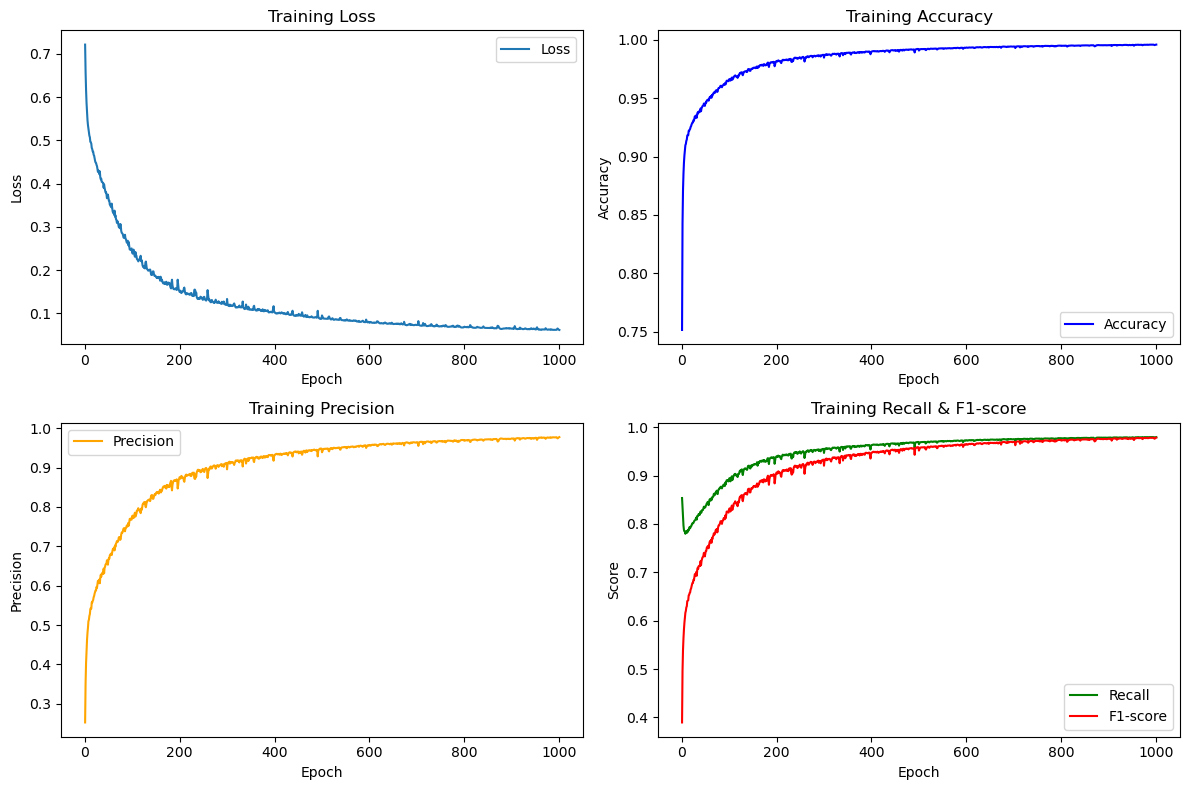

In [22]:
# 绘制曲线
plt.figure(figsize=(12, 8))

# 绘制 Loss 曲线
plt.subplot(2, 2, 1)
plt.plot(range(1, num_epochs + 1), losses, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(2, 2, 2)
plt.plot(range(1, num_epochs + 1), accuracies, label="Accuracy", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

# 绘制 Precision 曲线
plt.subplot(2, 2, 3)
plt.plot(range(1, num_epochs + 1), precisions, label="Precision", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training Precision")
plt.legend()

# 绘制 Recall 和 F1-score 曲线
plt.subplot(2, 2, 4)
plt.plot(range(1, num_epochs + 1), recalls, label="Recall", color="green")
plt.plot(range(1, num_epochs + 1), f1_scores, label="F1-score", color="red")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Recall & F1-score")
plt.legend()

plt.tight_layout()
plt.show()

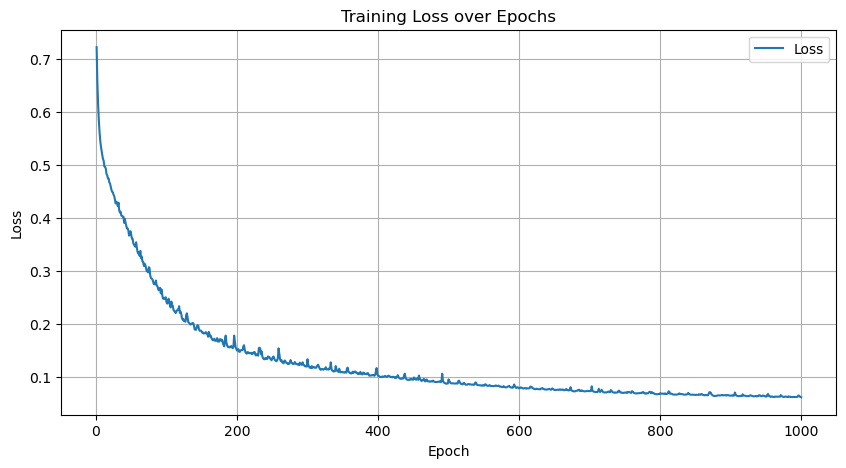

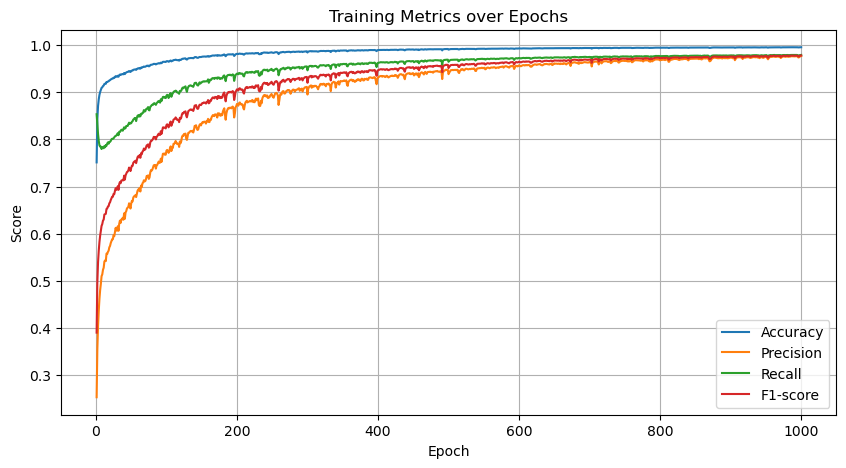

ValueError: x and y must have same first dimension, but have shapes (1000,) and (0,)

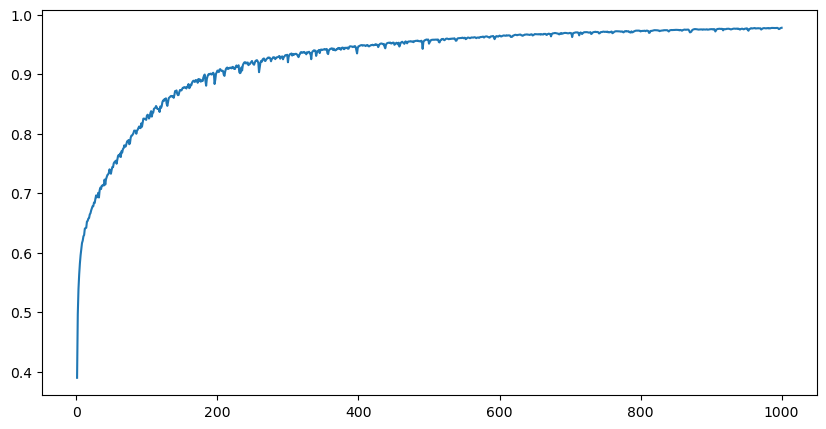

In [23]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(losses) + 1))

# 1. 学習曲線（Loss）
plt.figure(figsize=(10, 5))
plt.plot(epochs, losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 2. 評価指標の推移
plt.figure(figsize=(10, 5))
plt.plot(epochs, accuracies, label='Accuracy')
plt.plot(epochs, precisions, label='Precision')
plt.plot(epochs, recalls, label='Recall')
plt.plot(epochs, f1_scores, label='F1-score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Metrics over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 3. Train vs Test F1-score
plt.figure(figsize=(10, 5))
plt.plot(epochs, f1_scores, label='Train F1')
plt.plot(epochs, test_f1_scores, label='Test F1')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.title('Train vs Test F1-score')
plt.legend()
plt.grid(True)
plt.show()

Checkpoint loaded!


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:06<00:00, 14.33it/s]


Recall: 0.6833
Precision: 0.6625
F1-score: 0.6727
[[42454367  1577179]
 [ 1435037  3095593]]


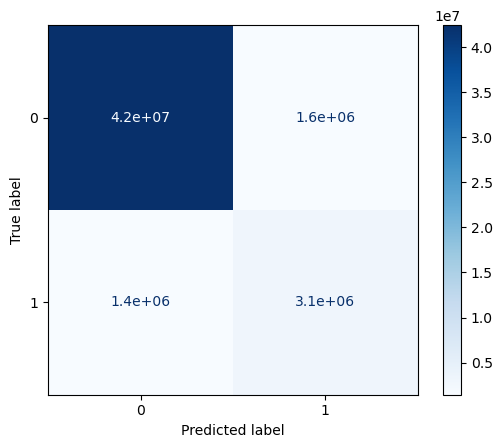

In [22]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# **学習の途中から再開**
save_path = "best_model.pth"
if os.path.exists(save_path):
    checkpoint = torch.load(save_path, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"Checkpoint loaded!")

# 假设模型已经加载并设置为评估模式
model.eval()

# 存储路径
#model_save_path = "buf/kifuku_newdataver3_model.pth"
#torch.save(model.state_dict(), model_save_path)
#print(f"Model saved to {model_save_path}")

# 在测试数据上进行评估
all_preds = []
all_targets = []

# 遍历测试集
with torch.no_grad():  # 禁用梯度计算
    for (dem,air), masks in tqdm(test_loader, desc="Evaluating"):
        dem,air, masks = dem.to(device),air.to(device), masks.to(device)
        

        # Forward pass
        outputs = model(dem,air)

        # 将输出值转换为二值预测（0 或 1）
        preds = (torch.sigmoid(outputs) > 0.5).float()  # 二值化
        all_preds.append(preds.cpu())  # 将数据从 GPU 转移到 CPU
        all_targets.append(masks.cpu())  # 将目标从 GPU 转移到 CPU

# 拼接所有批次的预测和标签
all_preds = torch.cat(all_preds).numpy().flatten()  # 转换为 NumPy 数组并展平
all_targets = torch.cat(all_targets).numpy().flatten()  # 转换为 NumPy 数组并展平

# 确保预测和标签为整数类型
all_preds = all_preds.astype(int)
all_targets = all_targets.astype(int)


# 计算 Recall、Precision 和 F1-score
recall = recall_score(all_targets, all_preds, zero_division=0)
precision = precision_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

# 打印评估指标
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

Checkpoint loaded!


Evaluating: 100%|██████████████████████████████████████████████████████████████████████| 93/93 [00:06<00:00, 15.16it/s]


Recall: 0.7025
Precision: 0.6714
F1-score: 0.6866
[[23894591   875562]
 [  757435  1788636]]


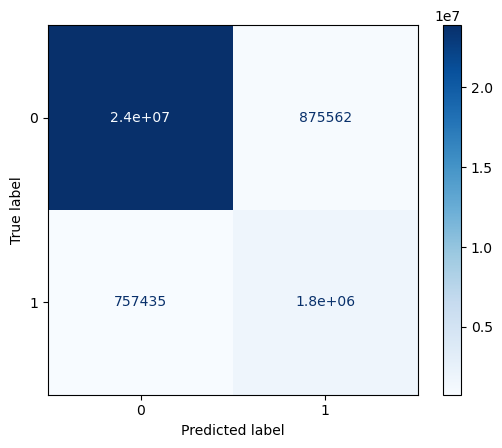

In [23]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# **学習の途中から再開**
save_path = "best_model.pth"
if os.path.exists(save_path):
    checkpoint = torch.load(save_path, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    print(f"Checkpoint loaded!")

# 假设模型已经加载并设置为评估模式
model.eval()

# 存储路径
#model_save_path = "buf/kifuku_newdataver3_model.pth"
#torch.save(model.state_dict(), model_save_path)
#print(f"Model saved to {model_save_path}")

# 在测试数据上进行评估
all_preds = []
all_targets = []
crop = 16  # 除去する境界幅（px）
# 遍历测试集
with torch.no_grad():  # 禁用梯度计算
    for (dem,air), masks in tqdm(test_loader, desc="Evaluating"):
        dem,air, masks = dem.to(device),air.to(device), masks.to(device)
        

        # Forward pass
        outputs = model(dem,air)

        # 将输出值转换为二值预测（0 或 1）
        preds = (torch.sigmoid(outputs) > 0.5).float()  # 二值化
        # 境界16pxを除去して中心96x96のみ評価
        preds  = preds[:, :, crop:-crop, crop:-crop]
        masks  = masks[:, :, crop:-crop, crop:-crop]
        all_preds.append(preds.cpu())  # 将数据从 GPU 转移到 CPU
        all_targets.append(masks.cpu())  # 将目标从 GPU 转移到 CPU

# 拼接所有批次的预测和标签
all_preds = torch.cat(all_preds).numpy().flatten()  # 转换为 NumPy 数组并展平
all_targets = torch.cat(all_targets).numpy().flatten()  # 转换为 NumPy 数组并展平

# 确保预测和标签为整数类型
all_preds = all_preds.astype(int)
all_targets = all_targets.astype(int)


# 计算 Recall、Precision 和 F1-score
recall = recall_score(all_targets, all_preds, zero_division=0)
precision = precision_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

# 打印评估指标
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

Generating Predictions: 100%|██████████████████████████████████████████████████████████| 93/93 [00:06<00:00, 14.75it/s]


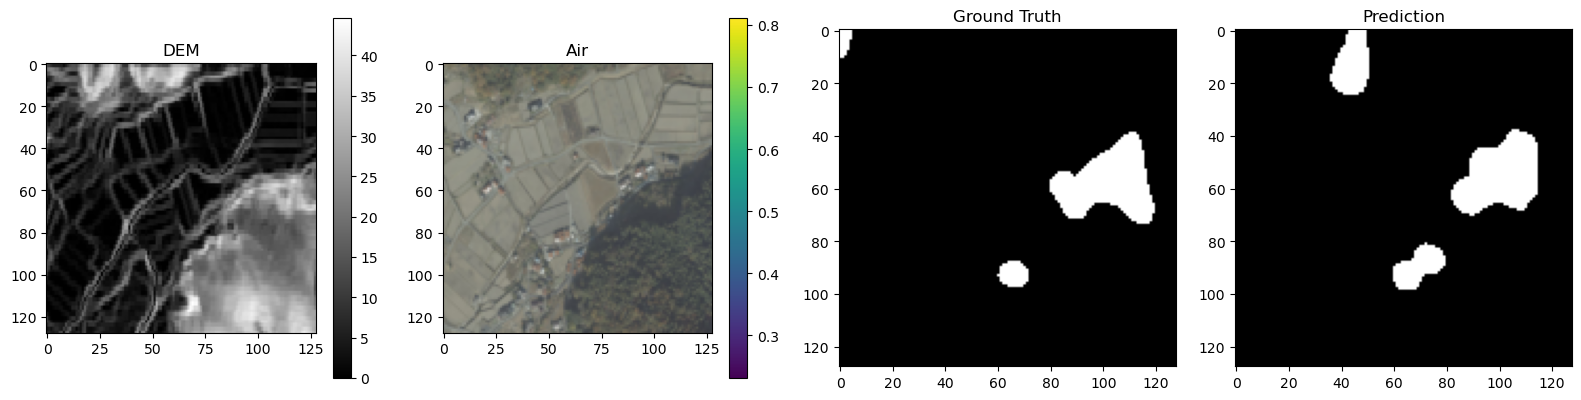

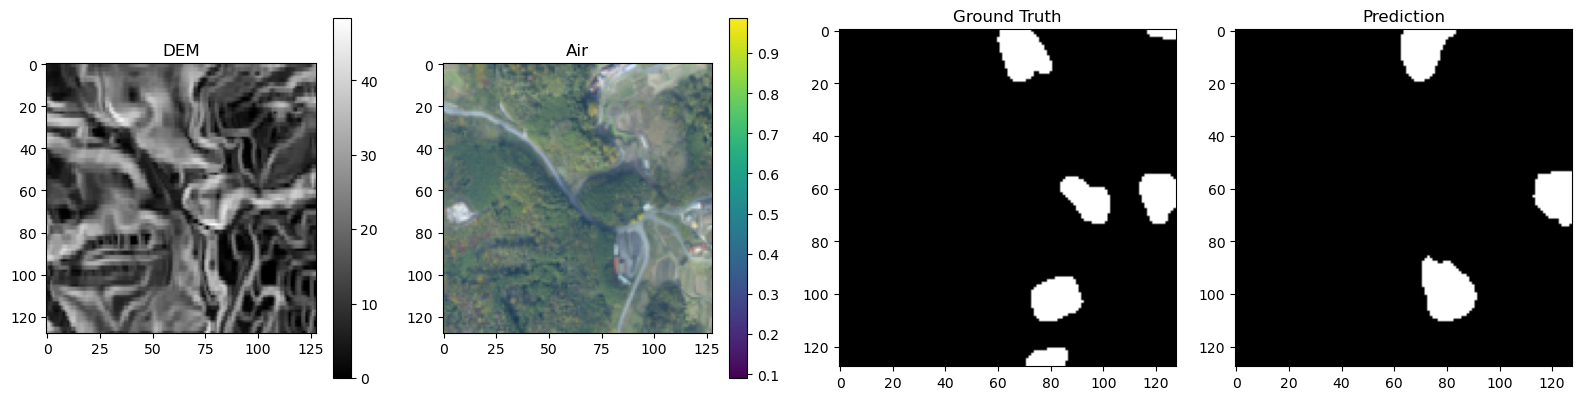

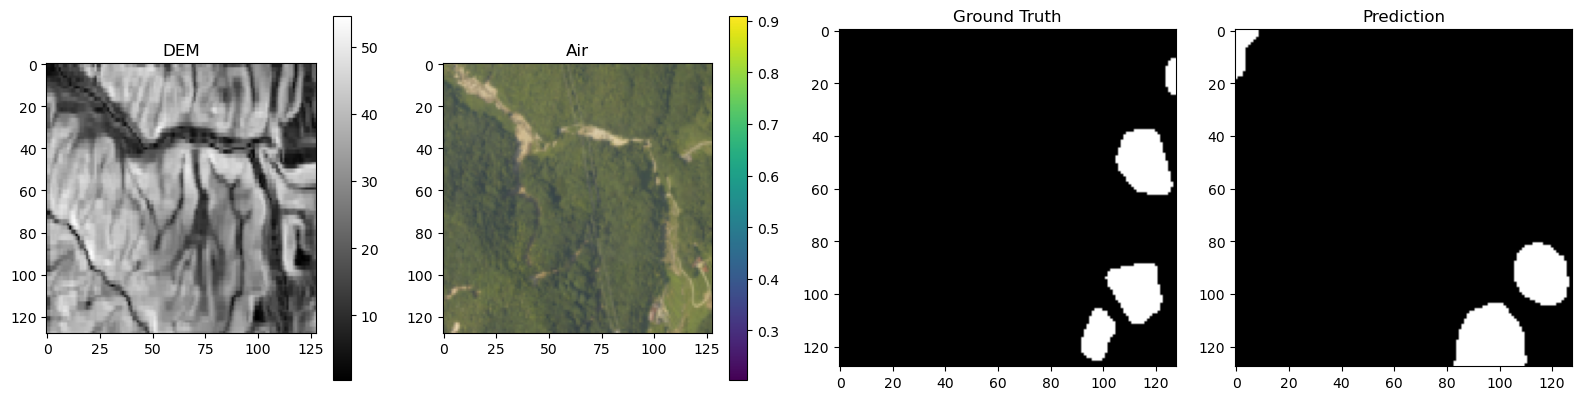

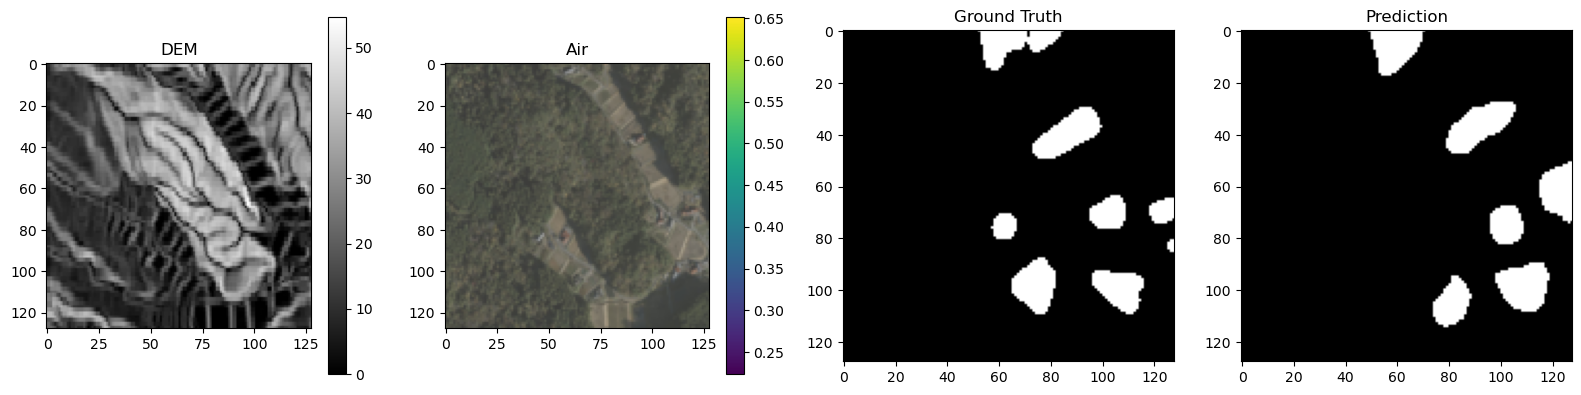

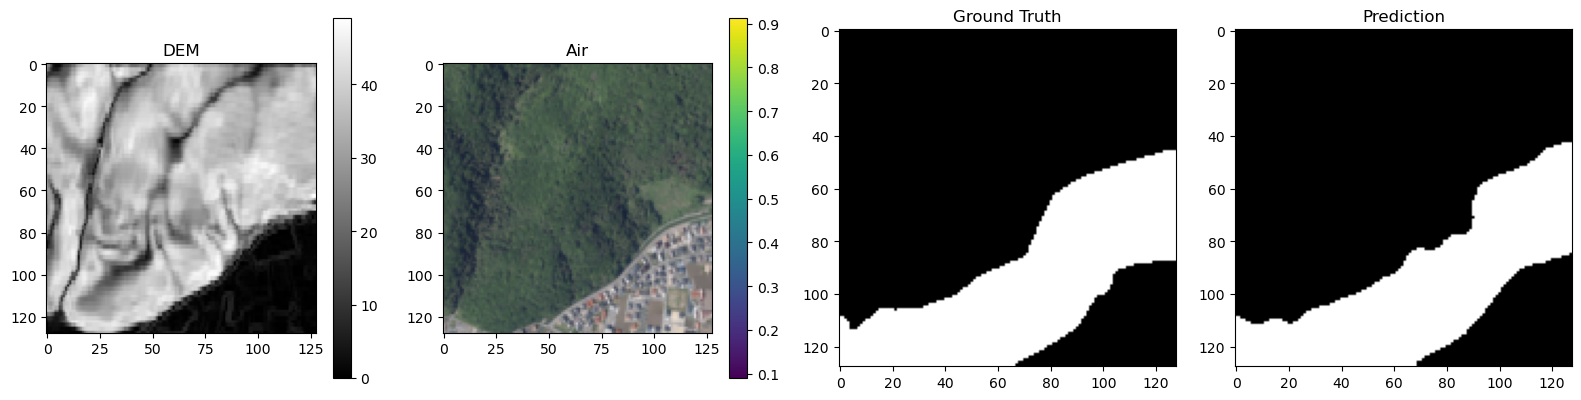

予測画像数: 2964


In [24]:
import os
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# 評価モード
model.eval()

predictions = []
dem_inputs = []
air_inputs = []
ground_truths = []

# 推論
with torch.no_grad():

    for (dem,air), masks in tqdm(
        test_loader,
        desc="Generating Predictions"
    ):

        #images = images.to(device)
        dem=dem.to(device)
        air=air.to(device)
        

        outputs = model(dem,air)

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        predictions.append(preds.cpu())
        dem_inputs.append(dem.cpu())
        air_inputs.append(air.cpu())
        ground_truths.append(masks.cpu())

# 結合
predictions = torch.cat(predictions).numpy()
dem_inputs = torch.cat(dem_inputs).numpy()
air_inputs = torch.cat(air_inputs).numpy()
ground_truths = torch.cat(ground_truths).numpy()

# 表示枚数
n_display = 5

for i in range(n_display):

    plt.figure(figsize=(16,4))

    # =====================
    # DEM
    # =====================
    plt.subplot(1,4,1)

    plt.title("DEM")

    plt.imshow(
        dem_inputs[i][0],
        cmap="gray"
    )

    plt.colorbar()

    # =====================
    # Fractal
    # =====================
    plt.subplot(1,4,2)

    plt.title("Air")

    plt.imshow(
        np.transpose(air_inputs[i],(1,2,0))
        
    )

    plt.colorbar()

    # =====================
    # Ground Truth
    # =====================
    plt.subplot(1,4,3)

    plt.title("Ground Truth")

    plt.imshow(
        ground_truths[i][0],
        cmap="gray"
    )

    # =====================
    # Prediction
    # =====================
    plt.subplot(1,4,4)

    plt.title("Prediction")

    plt.imshow(
        predictions[i][0],
        cmap="gray"
    )

    plt.tight_layout()

    plt.show()

print("予測画像数:", len(predictions))

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("losses.csv")

epochs = df["Epoch"]

losses = df["Loss"]
accuracies = df["Accuracy"]
precisions = df["Precision"]
recalls = df["Recall"]
f1_scores = df["F1-score"]
test_f1_scores = df["Test-F1-score"]

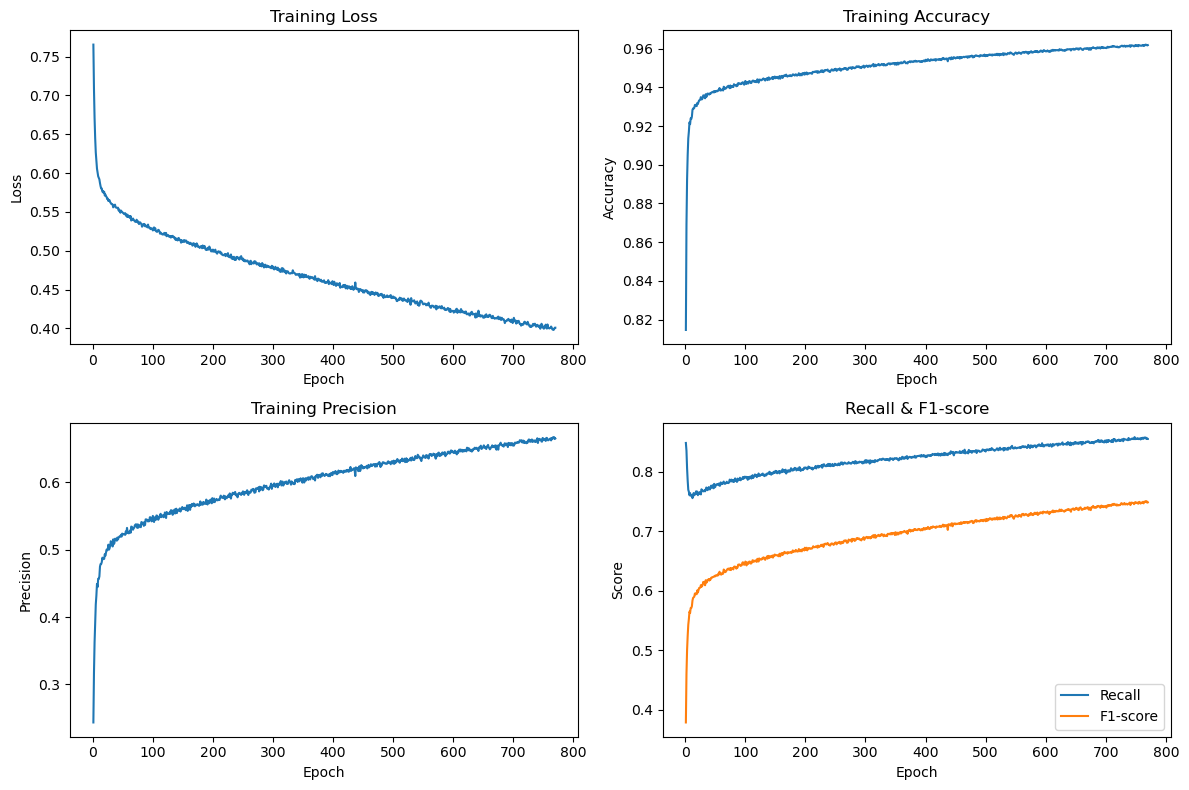

In [29]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.plot(epochs, losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.subplot(2,2,2)
plt.plot(epochs, accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.subplot(2,2,3)
plt.plot(epochs, precisions)
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training Precision")

plt.subplot(2,2,4)
plt.plot(epochs, recalls, label="Recall")
plt.plot(epochs, f1_scores, label="F1-score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Recall & F1-score")
plt.legend()

plt.tight_layout()
plt.show()

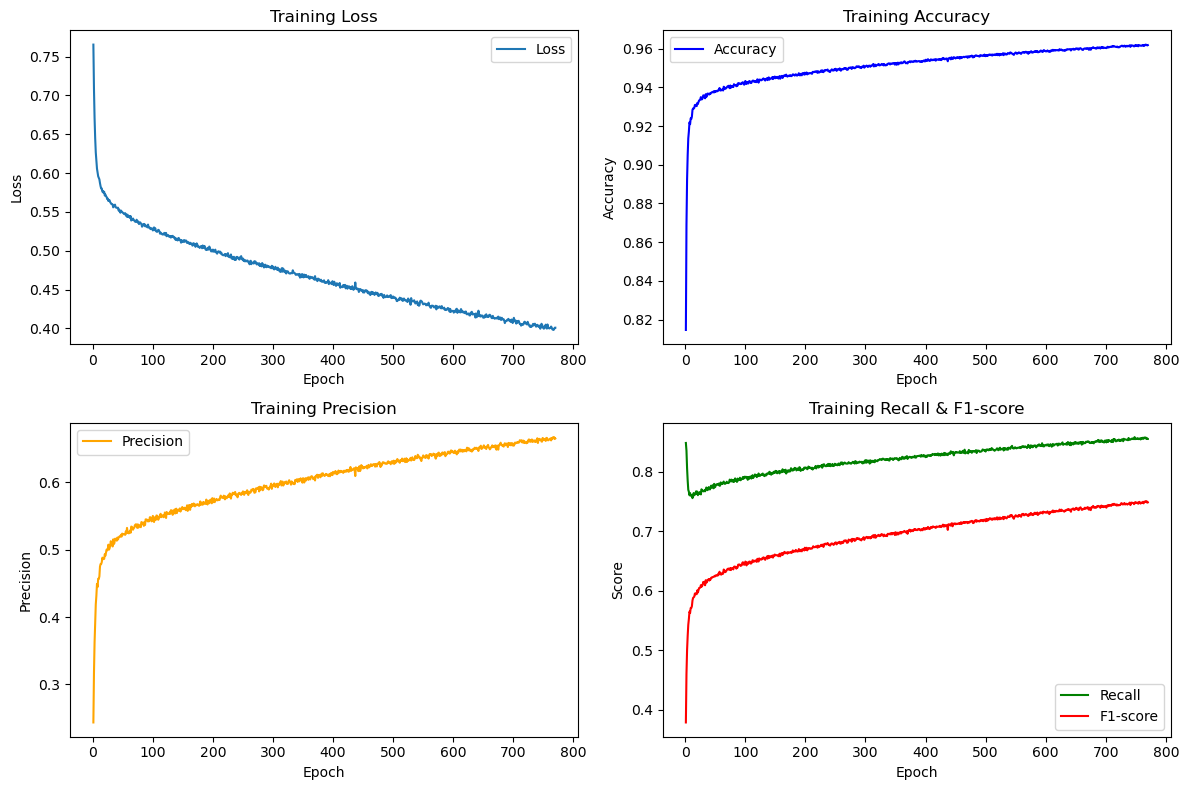

In [33]:
# 绘制曲线
plt.figure(figsize=(12, 8))

# 绘制 Loss 曲线
plt.subplot(2, 2, 1)
plt.plot(epochs, losses, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(2, 2, 2)
plt.plot(epochs, accuracies, label="Accuracy", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

# 绘制 Precision 曲线
plt.subplot(2, 2, 3)
plt.plot(epochs, precisions, label="Precision", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training Precision")
plt.legend()

# 绘制 Recall 和 F1-score 曲线
plt.subplot(2, 2, 4)
plt.plot(epochs, recalls, label="Recall", color="green")
plt.plot(epochs, f1_scores, label="F1-score", color="red")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Recall & F1-score")
plt.legend()

plt.tight_layout()
plt.show()

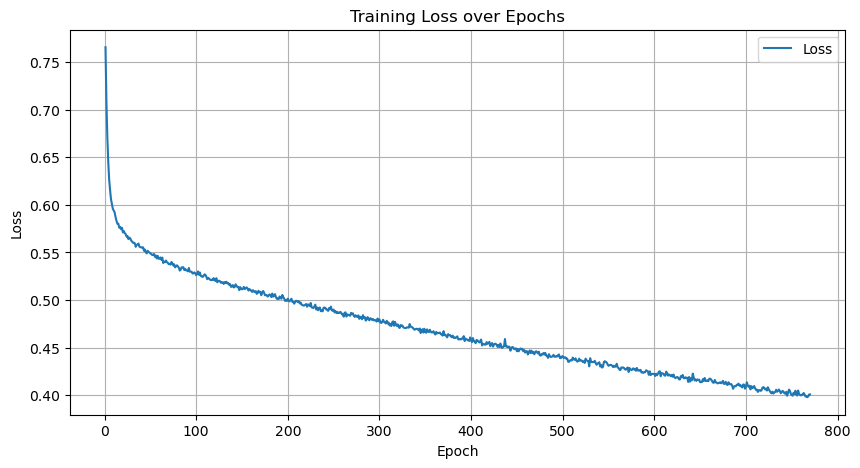

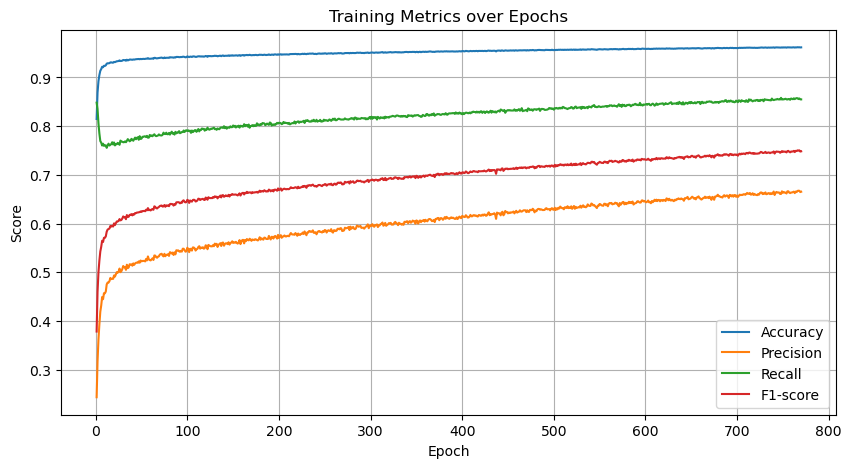

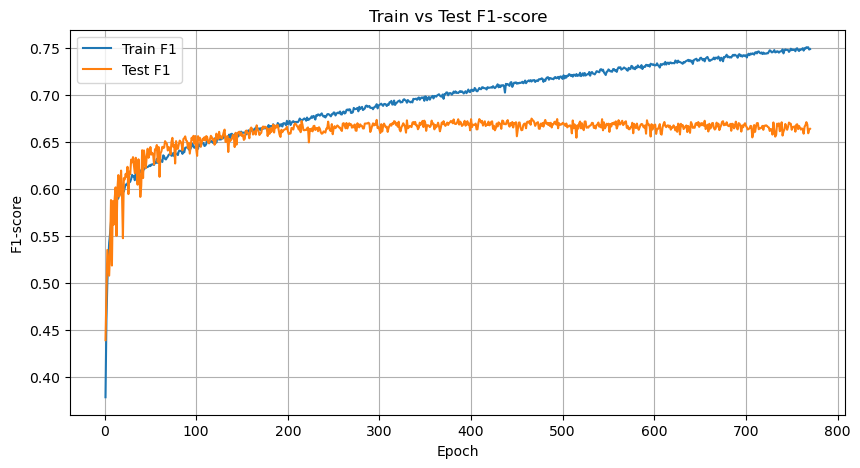

In [36]:
import matplotlib.pyplot as plt



# 1. 学習曲線（Loss）
plt.figure(figsize=(10, 5))
plt.plot(epochs, losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 2. 評価指標の推移
plt.figure(figsize=(10, 5))
plt.plot(epochs, accuracies, label='Accuracy')
plt.plot(epochs, precisions, label='Precision')
plt.plot(epochs, recalls, label='Recall')
plt.plot(epochs, f1_scores, label='F1-score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Training Metrics over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 3. Train vs Test F1-score
plt.figure(figsize=(10, 5))
plt.plot(epochs, f1_scores, label='Train F1')
plt.plot(epochs, test_f1_scores, label='Test F1')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.title('Train vs Test F1-score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test, No_train, No_test, xh_train, xh_test, nh_train, nh_test = train_test_split(dataset3.DEM, dataset3.Mask, dataset3.No, dataset3.Max_H, dataset3.Min_H, test_size=0.2, random_state=42)

## 島根県データセットでの汎化性能評価（SAM+APM / DEM+APM 条件）

広島データで学習したマルチ入力（DEM/SAM + AirPhoto）モデルを、島根県のデータ
（`load_any_dataset`経由で読み込み）で評価する。学習データと異なり、警戒区域を
含まない背景タイルも除外せず全て評価対象に含める。
評価はTP/FP/FN/TNをバッチごとに積算する方式で行い、大きなタイル数でも
メモリを圧迫しないようにしている。

In [ ]:
# ============================================================
# 1. 島根データの読み込み（SAM+APM または DEM+APM のpklを指定）
# ============================================================
shimane_path = "shimane_sam_apm.pkl"  # 実際のファイルパスに変更してください
shimane_raw = load_dataset(shimane_path)
print(f"島根データ タイル数: {len(shimane_raw.No)}")
print(f"DEM[0] shape: {np.array(shimane_raw.DEM[0]).shape}")
print(f"AirPhoto[0] shape: {np.array(shimane_raw.AirPhoto[0]).shape}")

# 【正規化についての注意】
# このノートブックの学習側では、DEM(SAM)フィールドに特別な正規化を適用しておらず、
# pklに入っている値をそのまま使っている（AirPhotoのみモデル入力直前に/255.0で0-1化）。
# そのため、島根側もbuild_shimane_dataset_v5.pyで生成した生のSAM値（度単位）を
# そのまま使う想定。学習データ側でDEMに別の正規化を適用した場合は、
# ここでも同じ変換を島根データに適用すること。

In [ ]:
# ============================================================
# 2. マスクにガウシアンフィルターを適用（学習時と同じ前処理）
#    学習データと違い、警戒区域を含まないタイルも除外せず全て使う
#    メモリ節約のため、AirPhoto/Maskはuint8のまま保持する
# ============================================================
from scipy.ndimage import gaussian_filter
import gc

shimane_dem_list = []
shimane_air_list = []
shimane_mask_list = []
for i in range(len(shimane_raw.No)):
    dem_i = np.array(shimane_raw.DEM[i], dtype=np.float32)
    air_i = np.array(shimane_raw.AirPhoto[i], dtype=np.uint8)
    mask_i = np.array(shimane_raw.Mask[i]).astype(np.uint8) * 255
    mask_i = gaussian_filter(mask_i, sigma=1)
    mask_i = (mask_i > 0).astype(np.uint8)
    shimane_dem_list.append(dem_i)
    shimane_air_list.append(air_i)
    shimane_mask_list.append(mask_i)

del shimane_raw
gc.collect()
print(f"タイル数: {len(shimane_dem_list)}")

In [ ]:
# ============================================================
# 3. 配列変換・Tensor化
#    AirPhoto/Maskはuint8のまま保持し、float化はDualInputDatasetの
#    __getitem__内でサンプル単位に行う（学習側と同じ方式でメモリ節約）
# ============================================================
shimane_dem_arr = np.array(shimane_dem_list, dtype=np.float32)
shimane_air_arr = np.array(shimane_air_list, dtype=np.uint8)
shimane_mask_arr = np.array(shimane_mask_list, dtype=np.uint8)
del shimane_dem_list, shimane_air_list, shimane_mask_list
gc.collect()

shimane_dem_arr = np.expand_dims(shimane_dem_arr, axis=1)          # [N, 1, H, W]
shimane_air_arr = np.transpose(shimane_air_arr, (0, 3, 1, 2))       # [N, 3, H, W] uint8のまま
shimane_mask_arr = np.expand_dims(shimane_mask_arr, axis=1)        # [N, 1, H, W] uint8のまま

X_dem_shimane = torch.from_numpy(shimane_dem_arr)   # float32
X_air_shimane = torch.from_numpy(shimane_air_arr)   # uint8
y_shimane = torch.from_numpy(shimane_mask_arr)      # uint8

print("DEM shape :", X_dem_shimane.shape, X_dem_shimane.dtype)
print("AirPhoto shape :", X_air_shimane.shape, X_air_shimane.dtype)
print("Mask shape :", y_shimane.shape, y_shimane.dtype)

In [ ]:
# ============================================================
# 4. DualInputDataset / DataLoader 作成
#    DualInputDatasetの__getitem__内でfloat化・正規化される
# ============================================================
shimane_dataset = DualInputDataset(
    X_dem_shimane,
    X_air_shimane,
    y_shimane
)
shimane_loader = DataLoader(
    shimane_dataset,
    batch_size=32,
    shuffle=False
)

for (dem, air), masks in shimane_loader:
    print("DEM:", dem.shape, dem.dtype, " AirPhoto:", air.shape, air.dtype, " Mask:", masks.shape, masks.dtype)
    break

In [ ]:
# ============================================================
# 5. 面積評価（全128x128）
#    TP/FP/FN/TNをバッチごとに積算する方式（巨大配列を作らない）
# ============================================================
model.eval()

tp_a = fp_a = fn_a = tn_a = 0

with torch.no_grad():
    for (dem, air), masks in tqdm(shimane_loader, desc="Evaluating on Shimane (full)"):
        dem, air, masks = dem.to(device), air.to(device), masks.to(device)
        outputs = model(dem, air)
        preds_bin = (torch.sigmoid(outputs) > 0.5)
        targets_bin = (masks > 0.5)

        tp_a += ((preds_bin) & (targets_bin)).sum().item()
        fp_a += ((preds_bin) & (~targets_bin)).sum().item()
        fn_a += ((~preds_bin) & (targets_bin)).sum().item()
        tn_a += ((~preds_bin) & (~targets_bin)).sum().item()

shimane_precision = tp_a / (tp_a + fp_a) if (tp_a + fp_a) > 0 else 0.0
shimane_recall = tp_a / (tp_a + fn_a) if (tp_a + fn_a) > 0 else 0.0
shimane_f1 = (2 * tp_a) / (2 * tp_a + fp_a + fn_a) if (2 * tp_a + fp_a + fn_a) > 0 else 0.0

print(f"[島根/面積評価] Recall: {shimane_recall:.4f}")
print(f"[島根/面積評価] Precision: {shimane_precision:.4f}")
print(f"[島根/面積評価] F1-score: {shimane_f1:.4f}")

shimane_cm = np.array([[tn_a, fp_a], [fn_a, tp_a]])
print(shimane_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=shimane_cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Shimane - Confusion Matrix (full)")
plt.show()

In [ ]:
# ============================================================
# 6. 境界評価（境界16pxを除去し中心96x96のみ）
#    こちらもTP/FP/FN/TNの積算方式
# ============================================================
model.eval()

tp_b = fp_b = fn_b = tn_b = 0
crop = 16

with torch.no_grad():
    for (dem, air), masks in tqdm(shimane_loader, desc="Evaluating on Shimane (border-cropped)"):
        dem, air, masks = dem.to(device), air.to(device), masks.to(device)
        outputs = model(dem, air)
        preds_bin = (torch.sigmoid(outputs) > 0.5)
        targets_bin = (masks > 0.5)

        preds_bin = preds_bin[:, :, crop:-crop, crop:-crop]
        targets_bin = targets_bin[:, :, crop:-crop, crop:-crop]

        tp_b += ((preds_bin) & (targets_bin)).sum().item()
        fp_b += ((preds_bin) & (~targets_bin)).sum().item()
        fn_b += ((~preds_bin) & (targets_bin)).sum().item()
        tn_b += ((~preds_bin) & (~targets_bin)).sum().item()

shimane_precision_b = tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else 0.0
shimane_recall_b = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0.0
shimane_f1_b = (2 * tp_b) / (2 * tp_b + fp_b + fn_b) if (2 * tp_b + fp_b + fn_b) > 0 else 0.0

print(f"[島根/境界評価] Recall: {shimane_recall_b:.4f}")
print(f"[島根/境界評価] Precision: {shimane_precision_b:.4f}")
print(f"[島根/境界評価] F1-score: {shimane_f1_b:.4f}")

shimane_cm_b = np.array([[tn_b, fp_b], [fn_b, tp_b]])
print(shimane_cm_b)
disp = ConfusionMatrixDisplay(confusion_matrix=shimane_cm_b)
disp.plot(cmap=plt.cm.Blues)
plt.title("Shimane - Confusion Matrix (border-cropped)")
plt.show()

In [ ]:
# ============================================================
# 7. 予測結果の目視確認（少数サンプルのみ抽出して表示、メモリ節約のため
#    全件をtorch.catせず、先頭1バッチだけ使う）
# ============================================================
model.eval()

n_display = 5
with torch.no_grad():
    for (dem, air), masks in shimane_loader:
        dem_d = dem.to(device)
        air_d = air.to(device)
        outputs = model(dem_d, air_d)
        preds = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        dem_np = dem.numpy()
        air_np = air.numpy()
        masks_np = masks.numpy()
        break  # 最初のバッチだけで十分

for i in range(min(n_display, dem_np.shape[0])):
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.title("DEM/SAM")
    plt.imshow(dem_np[i][0], cmap="gray")
    plt.colorbar()

    plt.subplot(1, 4, 2)
    plt.title("AirPhoto")
    plt.imshow(np.transpose(air_np[i], (1, 2, 0)))

    plt.subplot(1, 4, 3)
    plt.title("Ground Truth")
    plt.imshow(masks_np[i][0], cmap="gray")

    plt.subplot(1, 4, 4)
    plt.title("Prediction")
    plt.imshow(preds[i][0], cmap="gray")

    plt.tight_layout()
    plt.show()